In [106]:
import pandas as pd
import numpy as np

In [107]:
df = pd.read_csv("master_data_2020.csv")
df = df[~df["presvote20post"].isna()]

# ==========================================
# 1. DEFINE SOURCE COLUMNS
# ==========================================
treatment = "untrustworthy_flag"
raw_vote_choice_col = "presvote20post"

# ==========================================
# 2. OVERWRITE & CLEAN TARGET OUTCOMES FROM TEXT
# ==========================================
# Ensure we capture text responses and handle any trailing whitespaces cleanly
vote_series = df[raw_vote_choice_col].astype(str).str.strip()

# 1. Fix Biden Vote (1 if explicitly voted for Biden, 0 otherwise)
df["voted_biden_2020"] = np.where(vote_series == "Joe Biden", 1, 0)

# 2. Fix Trump Vote (1 if explicitly voted for Trump, 0 otherwise)
df["voted_trump_2020"] = np.where(vote_series == "Donald Trump", 1, 0)

# 3. Create Turnout (0 if they didn't vote or skipped, 1 if they cast a ballot)
# Based on your data, non-voters show up as "Did not vote for President" or missing strings
df["turnout_2020_binary"] = np.where(
    vote_series.str.contains("did not vote|skipped|__na__", case=False, na=True),
    0,
    1
)

# Structure our clean target dictionary for the loop
outcomes = {
    "2020 Turnout": "turnout_2020_binary",
    "Voted for Biden": "voted_biden_2020",
    "Voted for Trump": "voted_trump_2020",
}

# ==========================================
# 3. COMPREHENSIVE FEATURE ENGINEERING (CONDENSED & STREAMLINED)
# ==========================================
# Process Digital Literacy Index
tf_cols = ["tf_adv", "tf_pdf", "tf_spy", "tf_wiki", "tf_cache", "tf_phishing"]
df_tf = df[tf_cols].map(
    lambda val: int(str(val).strip().split()[0])
    if pd.notna(val) and str(val).strip().split()[0].isdigit()
    else np.nan
)
df["digital_literacy_index"] = df_tf.mean(axis=1)

# Linearized Political Mappings
df["ideo5_linear"] = df["ideo5"].map({"Very liberal": 1, "Liberal": 2, "Moderate": 3, "Conservative": 4, "Very conservative": 5})
df["pid7_linear"] = df["pid7"].map({"Strong Democrat": 1, "Not very strong Democrat": 2, "Lean Democrat": 3, "Independent": 4, "Lean Republican": 5, "Not very strong Republican": 6, "Strong Republican": 7})

# Linearized Social Media Scale
socmed_mapping = {
    "Less than 10 minutes per day": 1, "10–30 minutes per day": 2, "31–60 minutes per day": 3,
    "1–2 hours per day": 4, "2–3 hours per day": 5, "More than 3 hours per day": 6
}
df["socmed_use_linear"] = df["socmed_use"].astype(str).str.strip().map(socmed_mapping)

# --- NEW: Condense News Interest into a Linear Scale ---
newsint_mapping = {
    "Hardly at all": 1,
    "Only now and then": 2,
    "Some of the time": 3,
    "Most of the time": 4
}
df["newsint_linear"] = df["newsint"].astype(str).str.strip().map(newsint_mapping)

# --- NEW: Condense Internet Use Frequency into a Linear Scale ---
intuse_mapping = {
    "Less often": 1,
    "About once a day": 3,
    "Several times a day": 4,
    "A few times a week": 2  # Catching common top-tier survey labels if present
}
# Fallback to handle "Several times a day" as the top option if "Almost constantly" isn't used
df["intuse_linear"] = df["intuse"].astype(str).str.strip().map(intuse_mapping).fillna(3)

# --- NEW: Condense 2016 Vote into Trump, Clinton, and Other ---
# Modified 2016 vote processing function
def condense_2016_vote_fixed(val):
    val_str = str(val).strip()
    if val_str in ["Hillary Clinton", "Donald Trump"]:
        return val_str
    # Explicitly group non-voters and missing responses into a valid category string
    elif pd.isna(val) or val_str in ["__NA__", "nan", "Did not vote", "Did not vote for President"]:
        return "Did Not Vote"
    else:
        return "Other"

df["presvote16post_condensed"] = df["presvote16post"].apply(condense_2016_vote_fixed)

# REMOVE 'turnout16' from your categorical_covariates list!
# 'presvote16post_condensed' now handles turnout implicitly.
categorical_covariates = [
    "race4", 
    "educ4", 
    "region", 
    "presvote16post_condensed" # Will generate dummies for Clinton, Other, and Did Not Vote. 
]
# Gather all our dense numeric/linear features
linear_features = [
    "ideo5_linear", 
    "pid7_linear", 
    "socmed_use_linear", 
    "newsint_linear", 
    "intuse_linear"
]

# ==========================================
# 4. DESIGN MATRIX GENERATION (THE COVARIATES)
# ==========================================
core_cols = [treatment] + list(outcomes.values()) + ["age", "female"]
engineered_continuous = ["digital_literacy_index"]


# Clean complete-case alignment
all_processed_cols = core_cols + engineered_continuous + linear_features + categorical_covariates
df_clean = df[all_processed_cols].dropna().copy()

# Build the final compact X Matrix
# 1. Generate all dummies with drop_first=False so we can manually control the baselines
X_matrix = pd.get_dummies(
    df_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
)

# 2. Define exactly one baseline reference column to drop from each categorical group
baselines_to_drop = [
    'presvote16post_condensed_Donald Trump',  # 2016 Vote baseline
    'race4_White',                            # Race baseline
    'educ4_College grad',                     # Education baseline
    'region_Midwest',                         # Region baseline
]

# 3. Drop them safely from the matrix
X_matrix = X_matrix.drop(columns=baselines_to_drop, errors='ignore')

# ==========================================
# 5. FINAL AIPW INPUT EXTRACTION
# ==========================================
W = df_clean[treatment].astype(int).values
Y_turnout = df_clean[outcomes["2020 Turnout"]].astype(int).values
Y_biden = df_clean[outcomes["Voted for Biden"]].astype(int).values
Y_trump = df_clean[outcomes["Voted for Trump"]].astype(int).values

print("--- PIPELINE VERIFICATION ---")
print(f"Total valid sample size (N): {len(df_clean)}")
print(f"Total covariates in X_matrix: {X_matrix.shape[1]}")
print(f"Mean 2020 Turnout rate: {Y_turnout.mean():.2%}")
print(f"Mean unconditional Biden support: {Y_biden.mean():.2%}")
print(f"Mean unconditional Trump support: {Y_trump.mean():.2%}")

--- PIPELINE VERIFICATION ---
Total valid sample size (N): 956
Total covariates in X_matrix: 20
Mean 2020 Turnout rate: 97.38%
Mean unconditional Biden support: 59.73%
Mean unconditional Trump support: 35.46%


In [108]:
str(df.columns.tolist())

"['consent', 'encountered_fakenews1', 'fakenews_pctg1', 'fnews_story1', 'fnews_story2', 'fnews_story3', 'fnews_story4', 'fnews_story5', 'fnews_story6', 'fnews_story7', 'fnews_story8', 'fnews_story9', 'fnews_story0', 'certainty_nofakenews1', 'respondent_stories_1', 'respondent_stories_2', 'respondent_stories_3', 'respondent_stories_4', 'respondent_stories_5', 'respondent_stories_6', 'respondent_stories_7', 'respondent_stories_8', 'respondent_stories_9', 'respondent_stories_10', 'fnews_story1_source', 'fnews_story1_recognize', 'fnews_story2_source', 'fnews_story2_recognize', 'fnews_story3_source', 'fnews_story3_recognize', 'fnews_story4_source', 'fnews_story4_recognize', 'fnews_story5_source', 'fnews_story5_recognize', 'fnews_story6_source', 'fnews_story6_recognize', 'fnews_story7_source', 'fnews_story7_recognize', 'fnews_story8_source', 'fnews_story8_recognize', 'fnews_story9_source', 'fnews_story9_recognize', 'fnews_story0_source', 'fnews_story0_recognize', 'biggest_source1', 'biggest_

In [109]:
df["encountered_fakenews1"].value_counts(normalize=True)

encountered_fakenews1
A fair amount                           0.434650
Not very much                           0.243161
A great deal                            0.236069
I have not encountered any fake news    0.046606
Nearly all news I see is fake           0.039514
Name: proportion, dtype: float64

In [110]:
df['encountered_fakenews1_post'].value_counts(normalize=True)

encountered_fakenews1_post
A fair amount                           0.410516
Not very much                           0.265925
A great deal                            0.200202
I have not encountered any fake news    0.069767
Nearly all news I see is fake           0.053589
Name: proportion, dtype: float64

In [111]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

# 1. statsmodels requires an explicit intercept column
X_with_constant = sm.add_constant(X_matrix)

# Pack outcomes into a dictionary matching our extracted variables
outcome_data = {
    "Voted for Biden": Y_biden,
    "Voted for Trump": Y_trump
}

print("--- RUNNING LOGISTIC AIPW ESTIMATION (STATSMODELS) ---")

for name, Y in outcome_data.items():
    try:
        # ----------------------------------------------------
        # STEP 1: Propensity Score Model e(X) via pure MLE
        # ----------------------------------------------------
        prop_model = sm.Logit(W, X_with_constant).fit(disp=0, maxiter=1000)
        e_hat = prop_model.predict(X_with_constant)
        
        # Clip propensity scores to protect against extreme weights
        e_hat = np.clip(e_hat, 0.05, 0.95)
        
        # ----------------------------------------------------
        # STEP 2: Outcome Models mu_1(X) and mu_0(X)
        # ----------------------------------------------------
        # Fit model only on the treated units (W == 1)
        out_model_1 = sm.Logit(Y[W == 1], X_with_constant.iloc[W == 1]).fit(disp=0, maxiter=1000)
        mu_1_hat = out_model_1.predict(X_with_constant)
        
        # Fit model only on the control units (W == 0)
        out_model_0 = sm.Logit(Y[W == 0], X_with_constant.iloc[W == 0]).fit(disp=0, maxiter=1000)
        mu_0_hat = out_model_0.predict(X_with_constant)
        
        # ----------------------------------------------------
        # STEP 3: Compute AIPW Scores & Asymptotic Variance
        # ----------------------------------------------------
        N = len(Y)
        
        base_diff = mu_1_hat - mu_0_hat
        treated_correction = (W * (Y - mu_1_hat)) / e_hat
        control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)
        
        # Generate final point-level scores
        aipw_scores = base_diff + treated_correction - control_correction
        
        # Unbiased Average Treatment Effect (ATE)
        ate = np.mean(aipw_scores)
        
        # Analytical standard errors derived from the empirical influence curve
        influence_curve = aipw_scores - ate
        variance = np.var(influence_curve, ddof=1) / N
        std_error = np.sqrt(variance)
        
        # Compute Wald Z-Test statistics
        z_stat = ate / std_error
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
        
        # Confidence Intervals (95%)
        ci_lower = ate - (1.96 * std_error)
        ci_upper = ate + (1.96 * std_error)
        
        # ----------------------------------------------------
        # STEP 4: Print Clean Estimates
        # ----------------------------------------------------
        print(f"\nOutcome: {name}")
        print(f"  ATE: {ate:+.4f} ({ate*100:+.2f} percentage points)")
        print(f"  Std Error: {std_error:.4f}")
        print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
        print(f"  p-value:   {p_val:.4f}")
        
    except Exception as e:
        print(f"\nModel for '{name}' failed to converge or encountered an error:")
        print(f"  Error details: {e}")

--- RUNNING LOGISTIC AIPW ESTIMATION (STATSMODELS) ---

Outcome: Voted for Biden
  ATE: -0.0286 (-2.86 percentage points)
  Std Error: 0.0149
  95% CI:   [-0.0578, +0.0006]
  p-value:   0.0547

Outcome: Voted for Trump
  ATE: +0.0144 (+1.44 percentage points)
  Std Error: 0.0147
  95% CI:   [-0.0144, +0.0432]
  p-value:   0.3279


In [112]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier

# Use our clean master X_matrix values
X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}

# Native NumPy K-Fold generation
np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)

print("--- RUNNING LIGHTWEIGHT RANDOM FOREST AIPW ---")

for name, Y in candidate_outcomes.items():
    # Placeholders for out-of-fold probability predictions
    e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        # ----------------------------------------------------
        # STEP 1: Lightweight Propensity Score Model e(X)
        # ----------------------------------------------------
        # Max depth = 2 prevents hyper-partisans from getting 0.99 or 0.01 propensities
        prop_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        prop_model.fit(X_train, W_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

        # ----------------------------------------------------
        # STEP 2: Lightweight Outcome Models mu_1(X) and mu_0(X)
        # ----------------------------------------------------
        treated_mask = W_train == 1
        out_model_1 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask])
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

        control_mask = W_train == 0
        out_model_0 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask])
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

    # ----------------------------------------------------
    # STEP 3: Symmetric Trimming & AIPW Core Math
    # ----------------------------------------------------
    e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

    aipw_scores = base_diff + treated_correction - control_correction
    ate = np.mean(aipw_scores)

    # Asymptotic Standard Errors via Influence Curve
    influence_curve = aipw_scores - ate
    variance = np.var(influence_curve, ddof=1) / N
    std_error = np.sqrt(variance)

    # Inference Math
    z_stat = ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = ate - (1.96 * std_error)
    ci_upper = ate + (1.96 * std_error)

    print(f"\nOutcome: {name}")
    print(f"  ATE: {ate:+.4f} ({ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")

--- RUNNING LIGHTWEIGHT RANDOM FOREST AIPW ---

Outcome: Voted for Biden
  ATE: -0.0462 (-4.62 percentage points)
  Std Error: 0.0194
  95% CI:   [-0.0843, -0.0081]
  p-value:   0.0175

Outcome: Voted for Trump
  ATE: +0.0469 (+4.69 percentage points)
  Std Error: 0.0192
  95% CI:   [+0.0093, +0.0846]
  p-value:   0.0146


Fitting RF cross-fold models... done.

=== OVERLAP / COMMON SUPPORT DIAGNOSTIC ===
N=956  |  Treated=311  |  Control=645

Unclipped RF propensity scores:
  Full:     [0.0709, 0.7074]  mean=0.3290
  Treated:  [0.1115, 0.7074]  mean=0.3799
  Control:  [0.0709, 0.6711]  mean=0.3044

Tail mass at common trim thresholds:
  e(X) < 0.05:   0 (0.0%)   | e(X) > 0.95:   0 (0.0%)
  e(X) < 0.10:   6 (0.6%)   | e(X) > 0.90:   0 (0.0%)
  e(X) < 0.20: 128 (13.4%)   | e(X) > 0.80:   0 (0.0%)

IPW Effective Sample Size (Kish 1965):
  Treated ESS: 268  (raw n=311)
  Control ESS: 621  (raw n=645)
  Combined ESS/N: 93.0%


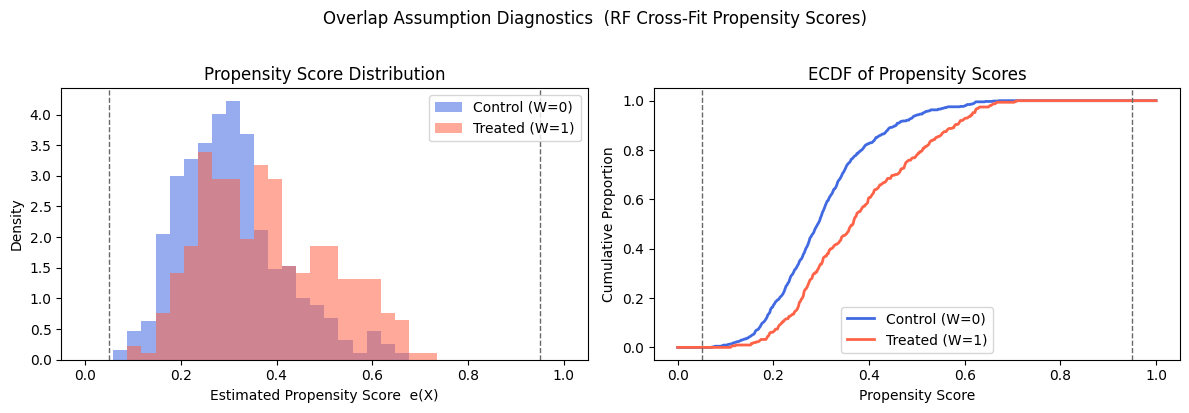

In [113]:
# ====================================================
# OVERLAP / COMMON SUPPORT CHECK  (RF Cross-Fit)
# ====================================================
# Re-runs the 5-fold RF cross-fitting from the cell above,
# storing all out-of-fold predictions for the sensitivity
# analysis below. Diagnostics use the unclipped scores.

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import numpy as np

X  = X_matrix.values
N  = len(W)
outcome_arrs = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}

np.random.seed(42)
idx = np.arange(N)
np.random.shuffle(idx)
folds = np.array_split(idx, 5)

e_hat_rf = np.zeros(N)
mu_1_rf  = {name: np.zeros(N) for name in outcome_arrs}
mu_0_rf  = {name: np.zeros(N) for name in outcome_arrs}

rf_kw = dict(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)

print("Fitting RF cross-fold models...", end=" ", flush=True)
for f in range(5):
    val_idx   = folds[f]
    train_idx = np.setdiff1d(idx, val_idx)
    X_tr, X_val = X[train_idx], X[val_idx]
    W_tr        = W[train_idx]

    e_hat_rf[val_idx] = (
        RandomForestClassifier(**rf_kw).fit(X_tr, W_tr).predict_proba(X_val)[:, 1]
    )

    for name, Y_full in outcome_arrs.items():
        Y_tr = Y_full[train_idx]
        mu_1_rf[name][val_idx] = (
            RandomForestClassifier(**rf_kw)
            .fit(X_tr[W_tr == 1], Y_tr[W_tr == 1])
            .predict_proba(X_val)[:, 1]
        )
        mu_0_rf[name][val_idx] = (
            RandomForestClassifier(**rf_kw)
            .fit(X_tr[W_tr == 0], Y_tr[W_tr == 0])
            .predict_proba(X_val)[:, 1]
        )
print("done.")

# ---------------------------------------------------------
# Overlap statistics on unclipped propensity scores
# ---------------------------------------------------------
e_raw = e_hat_rf
tr, ct = W == 1, W == 0

print("\n=== OVERLAP / COMMON SUPPORT DIAGNOSTIC ===")
print(f"N={N}  |  Treated={tr.sum()}  |  Control={ct.sum()}")
print(f"\nUnclipped RF propensity scores:")
print(f"  Full:     [{e_raw.min():.4f}, {e_raw.max():.4f}]  mean={e_raw.mean():.4f}")
print(f"  Treated:  [{e_raw[tr].min():.4f}, {e_raw[tr].max():.4f}]  mean={e_raw[tr].mean():.4f}")
print(f"  Control:  [{e_raw[ct].min():.4f}, {e_raw[ct].max():.4f}]  mean={e_raw[ct].mean():.4f}")

print(f"\nTail mass at common trim thresholds:")
for alpha in [0.05, 0.10, 0.20]:
    n_lo = (e_raw < alpha).sum()
    n_hi = (e_raw > 1 - alpha).sum()
    print(f"  e(X) < {alpha:.2f}: {n_lo:>3d} ({n_lo/N:.1%})   "
          f"| e(X) > {1-alpha:.2f}: {n_hi:>3d} ({n_hi/N:.1%})")

# Kish (1965) effective sample size under IPW
ess_t = (tr / e_raw).sum()**2 / (tr / e_raw**2).sum()
ess_c = (ct / (1-e_raw)).sum()**2 / (ct / (1-e_raw)**2).sum()
print(f"\nIPW Effective Sample Size (Kish 1965):")
print(f"  Treated ESS: {ess_t:.0f}  (raw n={tr.sum()})")
print(f"  Control ESS: {ess_c:.0f}  (raw n={ct.sum()})")
print(f"  Combined ESS/N: {(ess_t + ess_c)/N:.1%}")

# ---------------------------------------------------------
# Plots: histogram and ECDF
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 1, 35)
ax1.hist(e_raw[ct], bins=bins, alpha=0.55, color="royalblue", density=True, label="Control (W=0)")
ax1.hist(e_raw[tr], bins=bins, alpha=0.55, color="tomato",    density=True, label="Treated (W=1)")
for x in [0.05, 0.95]:
    ax1.axvline(x, color="dimgray", linestyle="--", lw=1)
ax1.set_xlabel("Estimated Propensity Score  e(X)")
ax1.set_ylabel("Density")
ax1.set_title("Propensity Score Distribution")
ax1.legend()

ps_grid = np.linspace(0, 1, 500)
ax2.plot(ps_grid, ECDF(e_raw[ct])(ps_grid), color="royalblue", lw=2, label="Control (W=0)")
ax2.plot(ps_grid, ECDF(e_raw[tr])(ps_grid), color="tomato",    lw=2, label="Treated (W=1)")
for x in [0.05, 0.95]:
    ax2.axvline(x, color="dimgray", linestyle="--", lw=1)
ax2.set_xlabel("Propensity Score")
ax2.set_ylabel("Cumulative Proportion")
ax2.set_title("ECDF of Propensity Scores")
ax2.legend()

plt.suptitle("Overlap Assumption Diagnostics  (RF Cross-Fit Propensity Scores)", y=1.02)
plt.tight_layout()
plt.show()


=== SENSITIVITY ANALYSIS (RF AIPW) ===

--- A. Trimming Sensitivity (hard trim, predictions held fixed) ---
   alpha      N   Biden ATE            Biden 95% CI   Trump ATE            Trump 95% CI
  -------------------------------------------------------------------------------------
  0.010    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]
  0.025    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]
  0.050    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]  <- baseline
  0.075    955    -0.0460  [-0.0841, -0.0079]    +0.0468  [+0.0091, +0.0845]
  0.100    950    -0.0454  [-0.0837, -0.0070]    +0.0463  [+0.0084, +0.0842]
  0.150    925    -0.0471  [-0.0852, -0.0089]    +0.0457  [+0.0076, +0.0838]
  0.200    828    -0.0475  [-0.0869, -0.0082]    +0.0475  [+0.0069, +0.0880]


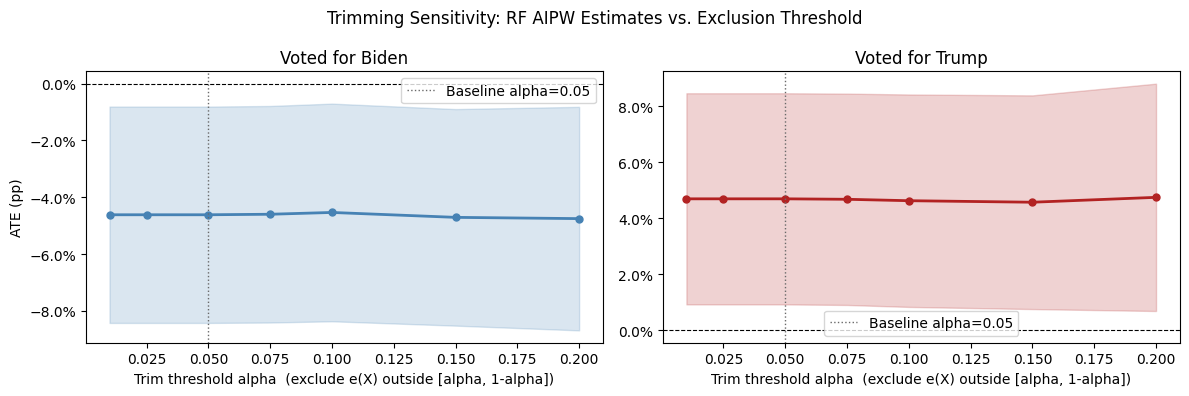


--- B. E-Values (alpha=0.05 baseline estimates) ---
  Interpretation: an unmeasured confounder with RR >= E with BOTH
  treatment and outcome is needed to fully explain away the effect.

  Outcome                   p0       ATE      RR    E(ATE)    CI bound    E(CI)
  -----------------------------------------------------------------------------
  Voted for Biden        0.671   -0.0462   1.074     1.355     -0.0081    1.123
  Voted for Trump        0.281   +0.0469   1.167     1.609     +0.0093    1.218

  Note: E(CI) is for the CI bound closest to zero.
  If the CI already crosses zero, E(CI) = 1.0 (trivially null).


In [114]:
# ====================================================
# SENSITIVITY ANALYSIS  (RF AIPW)
# ====================================================
# Uses e_hat_rf, mu_1_rf, mu_0_rf from the overlap cell.
#
# A. Trimming sensitivity  — how do RF AIPW estimates change
#    as we hard-trim units with extreme propensity scores?
# B. E-values (VanderWeele & Ding 2017) — minimum confounding
#    strength needed to explain away the observed effects.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ---------------------------------------------------------
# A. TRIMMING SENSITIVITY
# ---------------------------------------------------------
# For each threshold alpha, exclude units with e(X) outside
# [alpha, 1-alpha] and recompute AIPW on the retained sample.
# Cross-fitted predictions (mu_1_rf, mu_0_rf) are held fixed
# across thresholds -- a standard approximation for sensitivity.

alphas = [0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20]
trim_res = {name: dict(ate=[], ci_lo=[], ci_hi=[], n=[]) for name in outcome_arrs}

for alpha in alphas:
    keep = (e_hat_rf >= alpha) & (e_hat_rf <= 1 - alpha)
    e_k  = np.clip(e_hat_rf[keep], alpha, 1 - alpha)
    W_k  = W[keep]
    N_k  = keep.sum()

    for name in outcome_arrs:
        Y_k   = outcome_arrs[name][keep]
        mu1_k = mu_1_rf[name][keep]
        mu0_k = mu_0_rf[name][keep]

        psi = (mu1_k - mu0_k
               + (W_k * (Y_k - mu1_k)) / e_k
               - ((1 - W_k) * (Y_k - mu0_k)) / (1 - e_k))
        ate = psi.mean()
        se  = np.sqrt(psi.var(ddof=1) / N_k)
        trim_res[name]["ate"].append(ate)
        trim_res[name]["ci_lo"].append(ate - 1.96 * se)
        trim_res[name]["ci_hi"].append(ate + 1.96 * se)
        trim_res[name]["n"].append(N_k)

print("=== SENSITIVITY ANALYSIS (RF AIPW) ===\n")
print("--- A. Trimming Sensitivity (hard trim, predictions held fixed) ---")
hdr = (f"  {'alpha':>6}  {'N':>5}  {'Biden ATE':>10}  "
       f"{'Biden 95% CI':>22}  {'Trump ATE':>10}  {'Trump 95% CI':>22}")
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for i, alpha in enumerate(alphas):
    n  = trim_res["Voted for Biden"]["n"][i]
    b, bl, bh = (trim_res["Voted for Biden"]["ate"][i],
                 trim_res["Voted for Biden"]["ci_lo"][i],
                 trim_res["Voted for Biden"]["ci_hi"][i])
    t, tl, th = (trim_res["Voted for Trump"]["ate"][i],
                 trim_res["Voted for Trump"]["ci_lo"][i],
                 trim_res["Voted for Trump"]["ci_hi"][i])
    flag = "  <- baseline" if alpha == 0.05 else ""
    print(f"  {alpha:.3f}  {n:>5}  {b:>+9.4f}  [{bl:>+.4f}, {bh:>+.4f}]"
          f"  {t:>+9.4f}  [{tl:>+.4f}, {th:>+.4f}]{flag}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {"Voted for Biden": "steelblue", "Voted for Trump": "firebrick"}
for ax, name in zip(axes, trim_res):
    col  = palette[name]
    ates = trim_res[name]["ate"]
    lo   = trim_res[name]["ci_lo"]
    hi   = trim_res[name]["ci_hi"]
    ax.fill_between(alphas, lo, hi, alpha=0.20, color=col)
    ax.plot(alphas, ates, "o-", color=col, lw=2, ms=5)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.axvline(0.05, color="dimgray", linestyle=":", lw=1, label="Baseline alpha=0.05")
    ax.set_xlabel("Trim threshold alpha  (exclude e(X) outside [alpha, 1-alpha])")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("ATE (pp)")
plt.suptitle("Trimming Sensitivity: RF AIPW Estimates vs. Exclusion Threshold")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B. E-VALUES  (VanderWeele & Ding 2017, Ann. Intern. Med.)
# ---------------------------------------------------------
# The E-value is the minimum risk-ratio (RR) association that
# an unmeasured binary confounder must have with BOTH treatment
# AND outcome simultaneously to fully explain away the effect.
#
# Formula (RR >= 1):  E = RR + sqrt(RR * (RR - 1))
# We convert additive ATEs to approximate RRs using the
# control-group baseline rate, then compute E for both the
# point estimate and the CI bound closest to zero.

def _evalue(rr):
    rr = max(rr, 1.0)
    return rr + np.sqrt(rr * (rr - 1))

def rr_from_rd(rd, p0):
    p1 = np.clip(p0 + rd, 1e-6, 1 - 1e-6)
    rr = p1 / p0
    return rr if rr >= 1 else 1.0 / rr

p0_vals = {name: float(outcome_arrs[name][W == 0].mean()) for name in outcome_arrs}
base_i  = alphas.index(0.05)

print("\n--- B. E-Values (alpha=0.05 baseline estimates) ---")
print("  Interpretation: an unmeasured confounder with RR >= E with BOTH")
print("  treatment and outcome is needed to fully explain away the effect.")
print()
col_hdr = (f"  {'Outcome':<22} {'p0':>5}  {'ATE':>8}  "
           f"{'RR':>6}  {'E(ATE)':>8}  {'CI bound':>10}  {'E(CI)':>7}")
print(col_hdr)
print("  " + "-" * (len(col_hdr) - 2))

for name in ["Voted for Biden", "Voted for Trump"]:
    ate      = trim_res[name]["ate"][base_i]
    ci_lo    = trim_res[name]["ci_lo"][base_i]
    ci_hi    = trim_res[name]["ci_hi"][base_i]
    p0       = p0_vals[name]
    ci_bound = ci_hi if ate < 0 else ci_lo

    rr_ate = rr_from_rd(ate, p0)
    ev_ate = _evalue(rr_ate)
    rr_ci  = rr_from_rd(ci_bound, p0)
    ev_ci  = _evalue(rr_ci) if abs(ci_bound) > 0.001 else 1.0

    print(f"  {name:<22} {p0:.3f}  {ate:>+8.4f}  {rr_ate:>6.3f}"
          f"  {ev_ate:>8.3f}  {ci_bound:>+10.4f}  {ev_ci:>7.3f}")

print()
print("  Note: E(CI) is for the CI bound closest to zero.")
print("  If the CI already crosses zero, E(CI) = 1.0 (trivially null).")


In [115]:
# ====================================================
# NEGATIVE CONTROL OUTCOME ANALYSIS
# NOC: 2016 Presidential Vote (voted_trump_2016)
# ====================================================
# Logic: untrustworthy_flag captures 2020 fake news exposure.
# It is temporally impossible for 2020 exposure to have caused
# a respondent's 2016 vote.  Yet both outcomes share the same
# unmeasured confounders (stable partisan identity, right-wing
# information ecosystem, distrust of mainstream media).
#
# If ATE_NOC ≈ 0  → covariates are absorbing the confounding.
# If ATE_NOC ≠ 0  → residual confounding is detectable and its
#                   magnitude can be used to bias-correct:
#                   ATE_2020_calibrated = ATE_2020 − ATE_NOC
# ====================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier

# ----------------------------------------------------------
# 1. CONSTRUCT THE NOC OUTCOME
# ----------------------------------------------------------
df["voted_trump_2016"] = np.where(
    df["presvote16post"].astype(str).str.strip() == "Donald Trump", 1, 0
)

# ----------------------------------------------------------
# 2. BUILD NOC-SPECIFIC DESIGN MATRIX
#    Drop presvote16post_condensed — it IS the outcome now.
#    All other covariates stay the same.
# ----------------------------------------------------------
noc_categorical_covariates = ["race4", "educ4", "region"]   # no 2016-vote covariate
noc_linear_features        = linear_features                 # identical to main analysis
noc_core_cols = [treatment, "voted_trump_2016", "age", "female"]
noc_engineered = ["digital_literacy_index"]

noc_all_cols = noc_core_cols + noc_engineered + noc_linear_features + noc_categorical_covariates
df_noc = df[noc_all_cols].dropna().copy()

X_noc = pd.get_dummies(
    df_noc[["age", "female"] + noc_engineered + noc_linear_features + noc_categorical_covariates],
    columns=noc_categorical_covariates,
    drop_first=False,
    dtype=int,
).drop(columns=["race4_White", "educ4_College grad", "region_Midwest"], errors="ignore")

W_noc   = df_noc[treatment].astype(int).values
Y_noc   = df_noc["voted_trump_2016"].astype(int).values
N_noc   = len(W_noc)

print("=== NEGATIVE CONTROL OUTCOME (2016 Trump Vote) ===")
print(f"N={N_noc}  |  Treated={W_noc.sum()}  |  Control={(1-W_noc).sum()}")
print(f"NOC base rate (voted Trump 2016): {Y_noc.mean():.2%}")
print(f"Covariates in NOC X-matrix: {X_noc.shape[1]}  (2016-vote covariate removed)")

# ----------------------------------------------------------
# 3. PARAMETRIC AIPW (logistic, for reference)
# ----------------------------------------------------------
print("\n--- Parametric Logistic AIPW ---")
X_noc_const = sm.add_constant(X_noc)

prop_model = sm.Logit(W_noc, X_noc_const).fit(disp=0, maxiter=1000)
e_noc_logit = np.clip(prop_model.predict(X_noc_const), 0.05, 0.95)

out1_noc = sm.Logit(Y_noc[W_noc == 1], X_noc_const.iloc[W_noc == 1]).fit(disp=0, maxiter=1000)
out0_noc = sm.Logit(Y_noc[W_noc == 0], X_noc_const.iloc[W_noc == 0]).fit(disp=0, maxiter=1000)
mu1_noc_logit = out1_noc.predict(X_noc_const)
mu0_noc_logit = out0_noc.predict(X_noc_const)

psi_noc_logit = (
    (mu1_noc_logit - mu0_noc_logit)
    + (W_noc * (Y_noc - mu1_noc_logit)) / e_noc_logit
    - ((1 - W_noc) * (Y_noc - mu0_noc_logit)) / (1 - e_noc_logit)
)
ate_noc_logit = psi_noc_logit.mean()
se_noc_logit  = np.sqrt(psi_noc_logit.var(ddof=1) / N_noc)
z_noc_logit   = ate_noc_logit / se_noc_logit
p_noc_logit   = 2 * (1 - stats.norm.cdf(abs(z_noc_logit)))
print(f"  ATE (NOC): {ate_noc_logit:+.4f} ({ate_noc_logit*100:+.2f} pp)")
print(f"  95% CI:    [{ate_noc_logit - 1.96*se_noc_logit:+.4f}, {ate_noc_logit + 1.96*se_noc_logit:+.4f}]")
print(f"  p-value:   {p_noc_logit:.4f}")

# ----------------------------------------------------------
# 4. RF AIPW WITH 5-FOLD CROSS-FITTING (primary estimate)
# ----------------------------------------------------------
print("\n--- RF AIPW (5-fold cross-fit, primary NOC estimate) ---")

np.random.seed(42)
idx_noc   = np.arange(N_noc)
np.random.shuffle(idx_noc)
folds_noc = np.array_split(idx_noc, 5)

X_noc_arr = X_noc.values
e_noc_rf  = np.zeros(N_noc)
mu1_noc_rf = np.zeros(N_noc)
mu0_noc_rf = np.zeros(N_noc)

rf_kw = dict(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)

for f in range(5):
    val_idx   = folds_noc[f]
    train_idx = np.setdiff1d(idx_noc, val_idx)
    X_tr, X_val = X_noc_arr[train_idx], X_noc_arr[val_idx]
    W_tr, Y_tr  = W_noc[train_idx], Y_noc[train_idx]

    e_noc_rf[val_idx] = (
        RandomForestClassifier(**rf_kw).fit(X_tr, W_tr).predict_proba(X_val)[:, 1]
    )
    mu1_noc_rf[val_idx] = (
        RandomForestClassifier(**rf_kw)
        .fit(X_tr[W_tr == 1], Y_tr[W_tr == 1])
        .predict_proba(X_val)[:, 1]
    )
    mu0_noc_rf[val_idx] = (
        RandomForestClassifier(**rf_kw)
        .fit(X_tr[W_tr == 0], Y_tr[W_tr == 0])
        .predict_proba(X_val)[:, 1]
    )

e_noc_rf = np.clip(e_noc_rf, 0.05, 0.95)

psi_noc_rf = (
    (mu1_noc_rf - mu0_noc_rf)
    + (W_noc * (Y_noc - mu1_noc_rf)) / e_noc_rf
    - ((1 - W_noc) * (Y_noc - mu0_noc_rf)) / (1 - e_noc_rf)
)
ate_noc_rf = psi_noc_rf.mean()
se_noc_rf  = np.sqrt(psi_noc_rf.var(ddof=1) / N_noc)
z_noc_rf   = ate_noc_rf / se_noc_rf
p_noc_rf   = 2 * (1 - stats.norm.cdf(abs(z_noc_rf)))
ci_lo_noc  = ate_noc_rf - 1.96 * se_noc_rf
ci_hi_noc  = ate_noc_rf + 1.96 * se_noc_rf

print(f"  ATE (NOC): {ate_noc_rf:+.4f} ({ate_noc_rf*100:+.2f} pp)")
print(f"  95% CI:    [{ci_lo_noc:+.4f}, {ci_hi_noc:+.4f}]")
print(f"  p-value:   {p_noc_rf:.4f}")

# ----------------------------------------------------------
# 5. CALIBRATED 2020 ESTIMATES  (ATE_2020 − ATE_NOC)
# ----------------------------------------------------------
# Retrieve main RF AIPW estimates from the earlier cross-fit
# (stored in trim_res at alpha=0.05 index)
base_i = alphas.index(0.05)
ate_biden_main = trim_res["Voted for Biden"]["ate"][base_i]
ate_trump_main = trim_res["Voted for Trump"]["ate"][base_i]
se_biden_main  = (trim_res["Voted for Biden"]["ci_hi"][base_i] - trim_res["Voted for Biden"]["ci_lo"][base_i]) / (2 * 1.96)
se_trump_main  = (trim_res["Voted for Trump"]["ci_hi"][base_i] - trim_res["Voted for Trump"]["ci_lo"][base_i]) / (2 * 1.96)

ate_biden_cal = ate_biden_main - ate_noc_rf
ate_trump_cal = ate_trump_main - ate_noc_rf

# Delta-method SE: sqrt(SE_main^2 + SE_noc^2) — assumes independence
se_biden_cal  = np.sqrt(se_biden_main**2 + se_noc_rf**2)
se_trump_cal  = np.sqrt(se_trump_main**2 + se_noc_rf**2)

print("\n--- Calibrated 2020 Estimates  (ATE_2020 − ATE_NOC) ---")
print("  (Assumes bias structure is stable across 2016→2020 elections)")
header = f"  {'Outcome':<22}  {'Raw ATE':>9}  {'NOC Bias':>9}  {'Calibrated':>11}  {'95% CI (cal)':>22}"
print(header)
print("  " + "-" * (len(header) - 2))

for name, ate_main, se_main, ate_cal, se_cal in [
    ("Voted for Biden", ate_biden_main, se_biden_main, ate_biden_cal, se_biden_cal),
    ("Voted for Trump", ate_trump_main, se_trump_main, ate_trump_cal, se_trump_cal),
]:
    lo_cal = ate_cal - 1.96 * se_cal
    hi_cal = ate_cal + 1.96 * se_cal
    print(f"  {name:<22}  {ate_main:>+8.4f}  {ate_noc_rf:>+8.4f}  "
          f"{ate_cal:>+10.4f}  [{lo_cal:>+.4f}, {hi_cal:>+.4f}]")

print()
print("  NOC interpretation:")
if abs(p_noc_rf) < 0.05:
    print(f"  * NOC p={p_noc_rf:.3f} — residual confounding detected (ATE_NOC = {ate_noc_rf:+.4f}).")
    print(f"    Calibrated estimates subtract this bias.")
else:
    print(f"  * NOC p={p_noc_rf:.3f} — no statistically significant residual confounding.")
    print(f"    Raw 2020 estimates are plausible; calibration is a robustness check.")


=== NEGATIVE CONTROL OUTCOME (2016 Trump Vote) ===
N=956  |  Treated=311  |  Control=645
NOC base rate (voted Trump 2016): 29.60%
Covariates in NOC X-matrix: 17  (2016-vote covariate removed)

--- Parametric Logistic AIPW ---
  ATE (NOC): +0.0125 (+1.25 pp)
  95% CI:    [-0.0249, +0.0498]
  p-value:   0.5131

--- RF AIPW (5-fold cross-fit, primary NOC estimate) ---
  ATE (NOC): +0.0197 (+1.97 pp)
  95% CI:    [-0.0242, +0.0635]
  p-value:   0.3794

--- Calibrated 2020 Estimates  (ATE_2020 − ATE_NOC) ---
  (Assumes bias structure is stable across 2016→2020 elections)
  Outcome                   Raw ATE   NOC Bias   Calibrated            95% CI (cal)
  ---------------------------------------------------------------------------------
  Voted for Biden          -0.0462   +0.0197     -0.0658  [-0.1239, -0.0078]
  Voted for Trump          +0.0469   +0.0197     +0.0273  [-0.0305, +0.0851]

  NOC interpretation:
  * NOC p=0.379 — no statistically significant residual confounding.
    Raw 2020 

=== CONTINUOUS TREATMENT: untrustworthy_n ===
N=956  |  Covariates=20
Treatment  min=0  max=912  mean=8.16  median=0.0
  % zero: 67.5%  |  % 1-4: 20.1%  |  % 5+: 12.4%

Fitting cross-fold nuisance models... 

done.

--- DML θ̂: marginal effect per additional untrustworthy article ---

  Outcome: Voted for Biden
    θ̂:     -0.00016  (-0.0162 pp / article)
    95% CI: [-0.00028, -0.00004]
    p-val:  0.0070

  Outcome: Voted for Trump
    θ̂:     +0.00015  (+0.0146 pp / article)
    95% CI: [-0.00001, +0.00030]
    p-val:  0.0668

Fitting dose-response models on (T, X)... done.


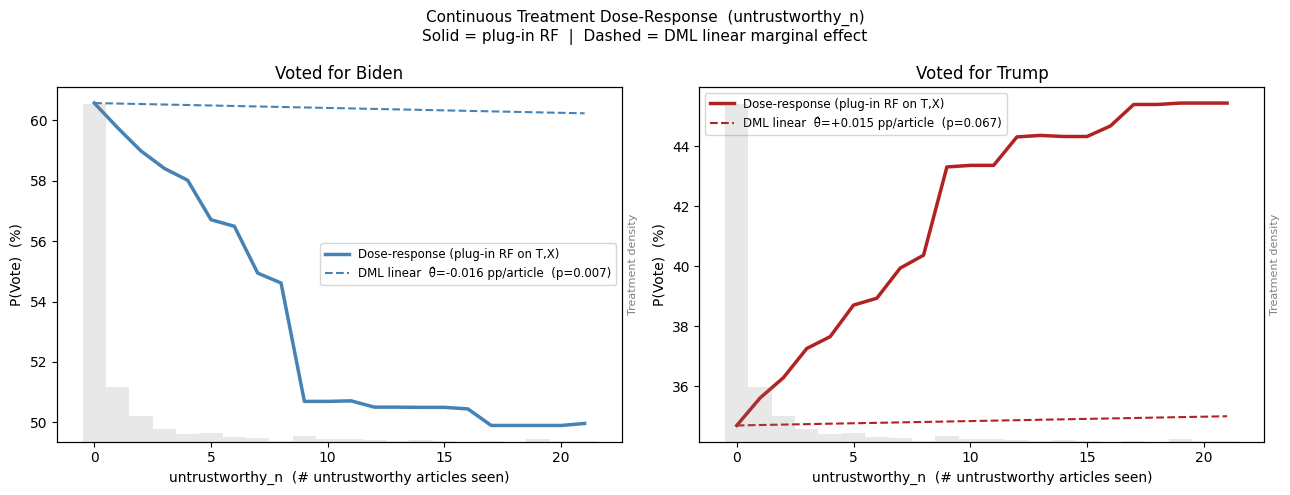


--- Comparison: binary ATE vs. DML continuous ---
  Binary ATE (RF AIPW, untrustworthy_flag 0→1) from earlier cell:
    Voted for Biden:  ~−4.6 pp   (see RF AIPW cell above)
    Voted for Trump:  ~+4.7 pp

  Mean untrustworthy_n | treated=25.09  control=0.00  gap≈25.09 articles

  DML-implied effect over that gap:
    Biden: θ̂ × gap = -0.41 pp
    Trump: θ̂ × gap = +0.37 pp
  (Should roughly match binary ATE if dose-response is linear in that range.)


In [116]:
# ====================================================
# CONTINUOUS TREATMENT: DML + DOSE-RESPONSE CURVE
# Treatment: untrustworthy_n (count of untrustworthy articles)
# ====================================================
# Double Machine Learning (DML) — Partially Linear Model:
#   Y = θ·T + g(X) + ε
# θ = marginal effect of one additional untrustworthy article.
#
# Cross-fit procedure (5-fold, Chernozhukov et al. 2018):
#   T̃ = T − E[T|X]   via RF Regressor
#   Ỹ = Y − E[Y|X]   via RF Classifier (probability residual)
#   θ̂ = Σ(T̃·Ỹ) / Σ(T̃²)   (Frisch-Waugh-Lovell on residuals)
#   SE via influence function: ψᵢ = T̃ᵢ(Ỹᵢ − θ̂T̃ᵢ) / E[T̃²]
#
# Dose-response curve E[Y(t)]:
#   Fit RF on features (T, X) jointly → plug in t for each
#   unit and average: E[Y(t)] = (1/N) Σᵢ μ̂(t, Xᵢ)
# ====================================================

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import scipy.stats as stats

# ----------------------------------------------------------
# 1. BUILD DATASET WITH CONTINUOUS TREATMENT
# ----------------------------------------------------------
cont_treatment = "untrustworthy_n"
cont_all_cols  = (
    [cont_treatment, treatment] + list(outcomes.values())  # treatment = untrustworthy_flag, needed for Section 6
    + ["age", "female"] + engineered_continuous
    + linear_features + categorical_covariates
)
df_cont = df[cont_all_cols].dropna().copy()

X_cont_df = pd.get_dummies(
    df_cont[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
).drop(columns=baselines_to_drop, errors="ignore")

X_c   = X_cont_df.values
T_c   = df_cont[cont_treatment].values.astype(float)
N_c   = len(T_c)
Y_biden_c = df_cont[outcomes["Voted for Biden"]].astype(int).values
Y_trump_c = df_cont[outcomes["Voted for Trump"]].astype(int).values

print("=== CONTINUOUS TREATMENT: untrustworthy_n ===")
print(f"N={N_c}  |  Covariates={X_c.shape[1]}")
print(f"Treatment  min={T_c.min():.0f}  max={T_c.max():.0f}"
      f"  mean={T_c.mean():.2f}  median={np.median(T_c):.1f}")
print(f"  % zero: {(T_c==0).mean():.1%}"
      f"  |  % 1-4: {((T_c>=1)&(T_c<5)).mean():.1%}"
      f"  |  % 5+: {(T_c>=5).mean():.1%}")

# ----------------------------------------------------------
# 2. 5-FOLD CROSS-FIT: nuisance models for T and Y
# ----------------------------------------------------------
np.random.seed(42)
idx_c   = np.arange(N_c)
np.random.shuffle(idx_c)
folds_c = np.array_split(idx_c, 5)

T_hat   = np.zeros(N_c)
Y_hat_b = np.zeros(N_c)   # E[Y_biden | X]
Y_hat_t = np.zeros(N_c)   # E[Y_trump | X]

rf_reg = dict(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_cls = dict(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)

print("\nFitting cross-fold nuisance models...", end=" ", flush=True)
for f in range(5):
    val_idx   = folds_c[f]
    train_idx = np.setdiff1d(idx_c, val_idx)
    X_tr, X_val = X_c[train_idx], X_c[val_idx]
    T_tr        = T_c[train_idx]

    # Treatment model: E[T | X]  — RF Regressor (T is a count)
    T_hat[val_idx] = (
        RandomForestRegressor(**rf_reg).fit(X_tr, T_tr).predict(X_val)
    )
    # Outcome models: E[Y | X]  — RF Classifier (no T as feature)
    Y_hat_b[val_idx] = (
        RandomForestClassifier(**rf_cls)
        .fit(X_tr, Y_biden_c[train_idx]).predict_proba(X_val)[:, 1]
    )
    Y_hat_t[val_idx] = (
        RandomForestClassifier(**rf_cls)
        .fit(X_tr, Y_trump_c[train_idx]).predict_proba(X_val)[:, 1]
    )
print("done.")

T_tilde = T_c - T_hat   # treatment residual: T̃

# ----------------------------------------------------------
# 3. DML ESTIMATE θ̂ WITH SANDWICH SE
# ----------------------------------------------------------
def dml_estimate(T_tilde, Y_arr, Y_hat):
    Y_tilde = Y_arr - Y_hat
    denom   = np.sum(T_tilde ** 2)
    theta   = np.sum(T_tilde * Y_tilde) / denom
    scores  = T_tilde * (Y_tilde - theta * T_tilde)
    IF      = scores / np.mean(T_tilde ** 2)
    se      = np.sqrt(np.mean(IF ** 2) / len(T_tilde))
    z       = theta / se
    p       = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(theta=theta, se=se, p=p,
                ci_lo=theta - 1.96*se, ci_hi=theta + 1.96*se)

res_b = dml_estimate(T_tilde, Y_biden_c, Y_hat_b)
res_t = dml_estimate(T_tilde, Y_trump_c, Y_hat_t)

print("\n--- DML θ̂: marginal effect per additional untrustworthy article ---")
for name, res in [("Voted for Biden", res_b), ("Voted for Trump", res_t)]:
    print(f"\n  Outcome: {name}")
    print(f"    θ̂:     {res['theta']:+.5f}  ({res['theta']*100:+.4f} pp / article)")
    print(f"    95% CI: [{res['ci_lo']:+.5f}, {res['ci_hi']:+.5f}]")
    print(f"    p-val:  {res['p']:.4f}")

# ----------------------------------------------------------
# 4. DOSE-RESPONSE CURVE  E[Y(t)] = (1/N) Σ μ̂(t, Xᵢ)
#    Fit RF on (T, X) jointly; predict at each grid point t.
# ----------------------------------------------------------
print("\nFitting dose-response models on (T, X)...", end=" ", flush=True)
TX = np.column_stack([T_c, X_c])

clf_b = RandomForestClassifier(**rf_cls).fit(TX, Y_biden_c)
clf_t = RandomForestClassifier(**rf_cls).fit(TX, Y_trump_c)
print("done.")

# Grid from 0 to 95th-percentile of T (avoid extrapolation)
t_grid = np.arange(0, np.percentile(T_c, 95) + 1, 1, dtype=float)
dr_b, dr_t = [], []

for t in t_grid:
    TX_t = np.column_stack([np.full(N_c, t), X_c])
    dr_b.append(clf_b.predict_proba(TX_t)[:, 1].mean())
    dr_t.append(clf_t.predict_proba(TX_t)[:, 1].mean())

dr_b = np.array(dr_b) * 100
dr_t = np.array(dr_t) * 100

# ----------------------------------------------------------
# 5. PLOT: dose-response + DML linear overlay + treatment rug
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {"Voted for Biden": ("steelblue", dr_b, res_b),
           "Voted for Trump": ("firebrick",  dr_t, res_t)}

for ax, (name, (col, dr, res)) in zip(axes, palette.items()):
    # Dose-response curve
    ax.plot(t_grid, dr, color=col, lw=2.5, label="Dose-response (plug-in RF on T,X)")

    # DML linear overlay: E[Y(0)] + θ̂·t   (linearized around t=0)
    linear = (dr[0] + res["theta"] * 100 * t_grid)
    ax.plot(t_grid, linear, color=col, lw=1.5, ls="--",
            label=f"DML linear  θ̂={res['theta']*100:+.3f} pp/article  (p={res['p']:.3f})")

    # Treatment density on secondary y-axis
    ax2 = ax.twinx()
    ax2.hist(T_c, bins=np.arange(0, t_grid.max() + 2) - 0.5,
             color="gray", alpha=0.18, density=True)
    ax2.set_yticks([])
    ax2.set_ylabel("Treatment density", color="gray", fontsize=8)

    ax.set_xlabel("untrustworthy_n  (# untrustworthy articles seen)")
    ax.set_ylabel("P(Vote)  (%)")
    ax.set_title(name)
    ax.legend(fontsize=8.5)

plt.suptitle(
    "Continuous Treatment Dose-Response  (untrustworthy_n)\n"
    "Solid = plug-in RF  |  Dashed = DML linear marginal effect",
    fontsize=11
)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. COMPARE TO BINARY ATE
# ----------------------------------------------------------
print("\n--- Comparison: binary ATE vs. DML continuous ---")
print("  Binary ATE (RF AIPW, untrustworthy_flag 0→1) from earlier cell:")
print("    Voted for Biden:  ~−4.6 pp   (see RF AIPW cell above)")
print("    Voted for Trump:  ~+4.7 pp")
T_treated_mean = T_c[df_cont[treatment].values == 1].mean()
T_control_mean = T_c[df_cont[treatment].values == 0].mean()
T_gap = T_treated_mean - T_control_mean
print(f"\n  Mean untrustworthy_n | treated={T_treated_mean:.2f}  control={T_control_mean:.2f}"
      f"  gap≈{T_gap:.2f} articles")
print(f"\n  DML-implied effect over that gap:")
print(f"    Biden: θ̂ × gap = {res_b['theta']*100*T_gap:+.2f} pp")
print(f"    Trump: θ̂ × gap = {res_t['theta']*100*T_gap:+.2f} pp")
print("  (Should roughly match binary ATE if dose-response is linear in that range.)")


=== RESTRICTED SAMPLE: untrustworthy_n ≤ 10 ===
N=886 (dropped 70 observations with untrustworthy_n > 10)
Treatment  min=0  max=10  mean=0.75  median=0.0
  % zero: 72.8%  |  % 1-4: 21.7%  |  % 5-10: 5.5%

Fitting cross-fold nuisance models... done.

--- DML θ̂ (restricted: untrustworthy_n ≤ 10) ---
  Comparison to unrestricted estimates in parentheses

  Outcome: Voted for Biden
    θ̂ (restricted): -0.01261  (-1.2606 pp/article)  vs. full: -0.0162 pp/article
    95% CI:  [-0.02311, -0.00211]
    p-val:   0.0186

  Outcome: Voted for Trump
    θ̂ (restricted): +0.01295  (+1.2947 pp/article)  vs. full: +0.0146 pp/article
    95% CI:  [+0.00091, +0.02498]
    p-val:   0.0350

Fitting dose-response models on (T, X)... done.


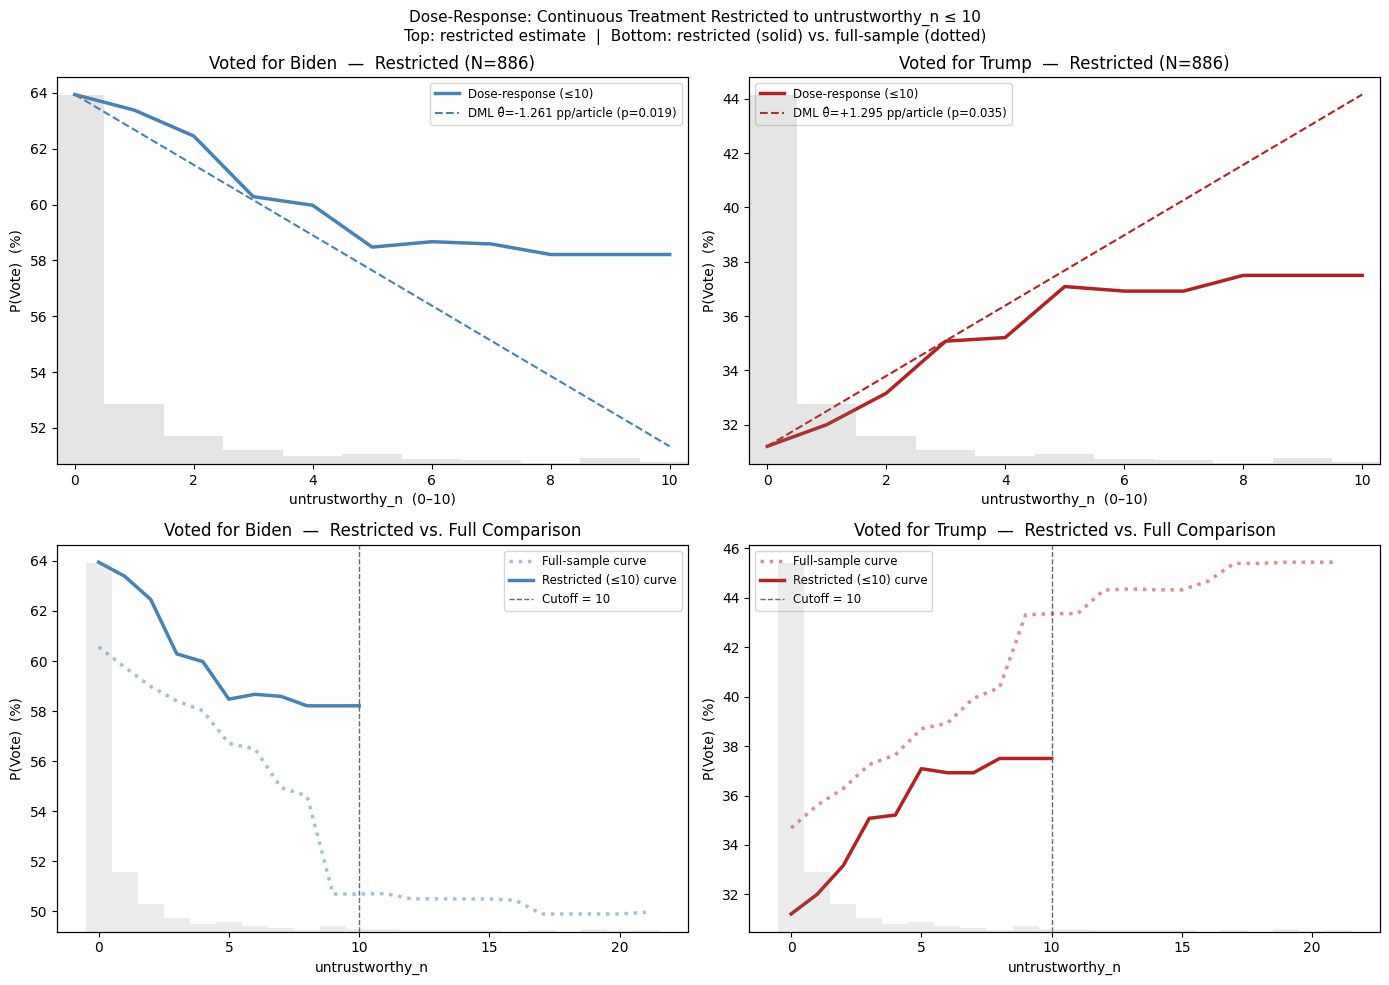


=== BINARY ATE vs. DML GAP (restricted: untrustworthy_n ≤ 10) ===

  Mean untrustworthy_n:
    Treated (flag=1): 2.76 articles
    Control (flag=0): 0.00 articles
    Gap:              +2.76 articles

  Outcome                 Binary ATE                95% CI   DML θ̂×gap    Match?
  --------------------------------------------------------------------------------
  Voted for Biden             -3.90pp  [-8.27, +0.48]       -3.48pp       yes
  Voted for Trump             +3.85pp  [-0.36, +8.06]       +3.57pp       yes

  Interpretation:
  - 'DML θ̂ × gap' rescales the per-article slope to the actual
    treated-vs-control exposure difference in this sample.
  - If it falls inside the binary ATE CI → the continuous and
    binary estimands are consistent; dose-response is approx linear
    between the two group means.
  - A large gap signals nonlinearity or that the binary threshold
    captures something beyond raw article count.


In [117]:
# ====================================================
# CONTINUOUS TREATMENT (RESTRICTED): untrustworthy_n <= 10
# ====================================================
# Repeats the DML + dose-response analysis on the subsample
# of respondents who saw at most 10 untrustworthy articles.
# Motivation:
#   - Concentrates on the data-dense region of the treatment
#     distribution where RF predictions are reliable.
#   - Avoids extrapolation into the sparse right tail.
#   - Tests whether the dose-response shape and DML θ̂ are
#     driven by the heavy-exposure outliers or are stable
#     across the typical range of exposure.
# ====================================================

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import scipy.stats as stats

MAX_T = 10

# ----------------------------------------------------------
# 1. RESTRICT DATASET TO untrustworthy_n <= MAX_T
# ----------------------------------------------------------
df_r = df_cont[df_cont[cont_treatment] <= MAX_T].copy()

X_r_df = pd.get_dummies(
    df_r[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
).drop(columns=baselines_to_drop, errors="ignore")

X_r   = X_r_df.values
T_r   = df_r[cont_treatment].values.astype(float)
N_r   = len(T_r)
Y_b_r = df_r[outcomes["Voted for Biden"]].astype(int).values
Y_t_r = df_r[outcomes["Voted for Trump"]].astype(int).values

print(f"=== RESTRICTED SAMPLE: untrustworthy_n ≤ {MAX_T} ===")
print(f"N={N_r} (dropped {len(df_cont)-N_r} observations with untrustworthy_n > {MAX_T})")
print(f"Treatment  min={T_r.min():.0f}  max={T_r.max():.0f}"
      f"  mean={T_r.mean():.2f}  median={np.median(T_r):.1f}")
print(f"  % zero: {(T_r==0).mean():.1%}"
      f"  |  % 1-4: {((T_r>=1)&(T_r<5)).mean():.1%}"
      f"  |  % 5-10: {((T_r>=5)&(T_r<=10)).mean():.1%}")

# ----------------------------------------------------------
# 2. 5-FOLD CROSS-FIT: nuisance models
# ----------------------------------------------------------
np.random.seed(42)
idx_r   = np.arange(N_r)
np.random.shuffle(idx_r)
folds_r = np.array_split(idx_r, 5)

T_hat_r   = np.zeros(N_r)
Y_hat_b_r = np.zeros(N_r)
Y_hat_t_r = np.zeros(N_r)

rf_reg = dict(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_cls = dict(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)

print("\nFitting cross-fold nuisance models...", end=" ", flush=True)
for f in range(5):
    val_idx   = folds_r[f]
    train_idx = np.setdiff1d(idx_r, val_idx)
    X_tr, X_val = X_r[train_idx], X_r[val_idx]
    T_tr        = T_r[train_idx]

    T_hat_r[val_idx] = (
        RandomForestRegressor(**rf_reg).fit(X_tr, T_tr).predict(X_val)
    )
    Y_hat_b_r[val_idx] = (
        RandomForestClassifier(**rf_cls)
        .fit(X_tr, Y_b_r[train_idx]).predict_proba(X_val)[:, 1]
    )
    Y_hat_t_r[val_idx] = (
        RandomForestClassifier(**rf_cls)
        .fit(X_tr, Y_t_r[train_idx]).predict_proba(X_val)[:, 1]
    )
print("done.")

T_tilde_r = T_r - T_hat_r

# ----------------------------------------------------------
# 3. DML ESTIMATE θ̂
# ----------------------------------------------------------
res_b_r = dml_estimate(T_tilde_r, Y_b_r, Y_hat_b_r)
res_t_r = dml_estimate(T_tilde_r, Y_t_r, Y_hat_t_r)

print(f"\n--- DML θ̂ (restricted: untrustworthy_n ≤ {MAX_T}) ---")
print(f"  Comparison to unrestricted estimates in parentheses\n")
for name, res_r, res_full in [
    ("Voted for Biden", res_b_r, res_b),
    ("Voted for Trump", res_t_r, res_t),
]:
    print(f"  Outcome: {name}")
    print(f"    θ̂ (restricted): {res_r['theta']:+.5f}  ({res_r['theta']*100:+.4f} pp/article)"
          f"  vs. full: {res_full['theta']*100:+.4f} pp/article")
    print(f"    95% CI:  [{res_r['ci_lo']:+.5f}, {res_r['ci_hi']:+.5f}]")
    print(f"    p-val:   {res_r['p']:.4f}\n")

# ----------------------------------------------------------
# 4. DOSE-RESPONSE CURVE (0 to MAX_T)
# ----------------------------------------------------------
print("Fitting dose-response models on (T, X)...", end=" ", flush=True)
TX_r  = np.column_stack([T_r, X_r])
clf_b_r = RandomForestClassifier(**rf_cls).fit(TX_r, Y_b_r)
clf_t_r = RandomForestClassifier(**rf_cls).fit(TX_r, Y_t_r)
print("done.")

t_grid_r = np.arange(0, MAX_T + 1, dtype=float)
dr_b_r, dr_t_r = [], []

for t in t_grid_r:
    TX_t = np.column_stack([np.full(N_r, t), X_r])
    dr_b_r.append(clf_b_r.predict_proba(TX_t)[:, 1].mean())
    dr_t_r.append(clf_t_r.predict_proba(TX_t)[:, 1].mean())

dr_b_r = np.array(dr_b_r) * 100
dr_t_r = np.array(dr_t_r) * 100

# ----------------------------------------------------------
# 5. PLOT — side by side: restricted vs. full-sample curve
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette_r = {
    "Voted for Biden": ("steelblue", dr_b_r, res_b_r, dr_b, res_b),
    "Voted for Trump": ("firebrick",  dr_t_r, res_t_r, dr_t, res_t),
}

for col_idx, (name, (col, dr_r, res_r, dr_full, res_full)) in enumerate(palette_r.items()):

    # --- Top row: restricted curve ---
    ax = axes[0, col_idx]
    ax.plot(t_grid_r, dr_r, color=col, lw=2.5, label=f"Dose-response (≤{MAX_T})")
    linear_r = dr_r[0] + res_r["theta"] * 100 * t_grid_r
    ax.plot(t_grid_r, linear_r, color=col, lw=1.5, ls="--",
            label=f"DML θ̂={res_r['theta']*100:+.3f} pp/article (p={res_r['p']:.3f})")
    ax2 = ax.twinx()
    ax2.hist(T_r, bins=np.arange(0, MAX_T + 2) - 0.5, color="gray", alpha=0.20, density=True)
    ax2.set_yticks([])
    ax.set_xlim(-0.3, MAX_T + 0.3)
    ax.set_xlabel(f"untrustworthy_n  (0–{MAX_T})")
    ax.set_ylabel("P(Vote)  (%)")
    ax.set_title(f"{name}  —  Restricted (N={N_r})")
    ax.legend(fontsize=8.5)

    # --- Bottom row: full-sample curve for comparison ---
    ax = axes[1, col_idx]
    t_full = np.arange(0, len(dr_full), dtype=float)
    ax.plot(t_full, dr_full, color=col, lw=2.5, alpha=0.5, ls=":", label="Full-sample curve")
    ax.plot(t_grid_r, dr_r, color=col, lw=2.5, label=f"Restricted (≤{MAX_T}) curve")
    ax.axvline(MAX_T, color="dimgray", ls="--", lw=1, label=f"Cutoff = {MAX_T}")
    ax2 = ax.twinx()
    ax2.hist(T_c, bins=np.arange(0, len(dr_full) + 1) - 0.5,
             color="gray", alpha=0.15, density=True)
    ax2.set_yticks([])
    ax.set_xlabel("untrustworthy_n")
    ax.set_ylabel("P(Vote)  (%)")
    ax.set_title(f"{name}  —  Restricted vs. Full Comparison")
    ax.legend(fontsize=8.5)

plt.suptitle(
    f"Dose-Response: Continuous Treatment Restricted to untrustworthy_n ≤ {MAX_T}\n"
    "Top: restricted estimate  |  Bottom: restricted (solid) vs. full-sample (dotted)",
    fontsize=11
)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. BINARY ATE vs. DML GAP COMPARISON (restricted sample)
# ----------------------------------------------------------
# The binary ATE (untrustworthy_flag 0→1) and the DML θ̂ answer
# slightly different questions. We can reconcile them by asking:
# "How many more untrustworthy articles did treated units see
#  compared to control units, within the restricted sample?"
# θ̂ × gap should approximate the binary ATE if the dose-response
# is approximately linear between the two group means.
# ----------------------------------------------------------
W_r = df_r[treatment].values.astype(int)   # binary flag in restricted sample

T_treated_r = T_r[W_r == 1].mean()
T_control_r = T_r[W_r == 0].mean()
T_gap_r     = T_treated_r - T_control_r

# Binary ATE in the restricted sample: re-run AIPW on df_r
# Use cross-fitted propensity + outcome from nuisance step above,
# substituting W_r as treatment
e_hat_r = np.zeros(N_r)
mu1_b_r = np.zeros(N_r)
mu0_b_r = np.zeros(N_r)
mu1_t_r = np.zeros(N_r)
mu0_t_r = np.zeros(N_r)

for f in range(5):
    val_idx   = folds_r[f]
    train_idx = np.setdiff1d(idx_r, val_idx)
    X_tr, X_val = X_r[train_idx], X_r[val_idx]
    W_tr        = W_r[train_idx]

    e_hat_r[val_idx] = (
        RandomForestClassifier(**rf_cls).fit(X_tr, W_tr).predict_proba(X_val)[:, 1]
    )
    for Y_full, mu1, mu0 in [
        (Y_b_r, mu1_b_r, mu0_b_r),
        (Y_t_r, mu1_t_r, mu0_t_r),
    ]:
        Y_tr = Y_full[train_idx]
        mu1[val_idx] = (
            RandomForestClassifier(**rf_cls)
            .fit(X_tr[W_tr==1], Y_tr[W_tr==1]).predict_proba(X_val)[:, 1]
        )
        mu0[val_idx] = (
            RandomForestClassifier(**rf_cls)
            .fit(X_tr[W_tr==0], Y_tr[W_tr==0]).predict_proba(X_val)[:, 1]
        )

e_hat_r = np.clip(e_hat_r, 0.05, 0.95)

def aipw_ate(W, Y, e, mu1, mu0):
    psi = (mu1 - mu0
           + W * (Y - mu1) / e
           - (1 - W) * (Y - mu0) / (1 - e))
    ate = psi.mean()
    se  = np.sqrt(psi.var(ddof=1) / len(psi))
    z   = ate / se
    p   = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(ate=ate, se=se, p=p,
                ci_lo=ate - 1.96*se, ci_hi=ate + 1.96*se)

bin_b_r = aipw_ate(W_r, Y_b_r, e_hat_r, mu1_b_r, mu0_b_r)
bin_t_r = aipw_ate(W_r, Y_t_r, e_hat_r, mu1_t_r, mu0_t_r)

print(f"\n=== BINARY ATE vs. DML GAP (restricted: untrustworthy_n ≤ {MAX_T}) ===")
print(f"\n  Mean untrustworthy_n:")
print(f"    Treated (flag=1): {T_treated_r:.2f} articles")
print(f"    Control (flag=0): {T_control_r:.2f} articles")
print(f"    Gap:              {T_gap_r:+.2f} articles")

header = (f"\n  {'Outcome':<22}  {'Binary ATE':>10}  {'95% CI':>20}"
          f"  {'DML θ̂×gap':>11}  {'Match?':>8}")
print(header)
print("  " + "-" * (len(header) - 2))

for name, bin_res, dml_res in [
    ("Voted for Biden", bin_b_r, res_b_r),
    ("Voted for Trump", bin_t_r, res_t_r),
]:
    implied = dml_res["theta"] * 100 * T_gap_r
    binary  = bin_res["ate"] * 100
    ci_lo   = bin_res["ci_lo"] * 100
    ci_hi   = bin_res["ci_hi"] * 100
    # "match" if DML-implied falls inside the binary ATE 95% CI
    match = "yes" if ci_lo <= implied <= ci_hi else "no"
    print(f"  {name:<22}  {binary:>+9.2f}pp  [{ci_lo:>+.2f}, {ci_hi:>+.2f}]"
          f"  {implied:>+10.2f}pp  {match:>8}")

print()
print("  Interpretation:")
print("  - 'DML θ̂ × gap' rescales the per-article slope to the actual")
print("    treated-vs-control exposure difference in this sample.")
print("  - If it falls inside the binary ATE CI → the continuous and")
print("    binary estimands are consistent; dose-response is approx linear")
print("    between the two group means.")
print("  - A large gap signals nonlinearity or that the binary threshold")
print("    captures something beyond raw article count.")
